---
title: "1-1 R-R (Python conversion)"
date: "2025-07-13"
---

> Converted from R Markdown to a Python-kernel Jupyter Notebook. Update `DATA_PATH` before running.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# TODO: change this to the real location of moduleTable.txt
DATA_PATH = Path("moduleTable.txt")
OUTPUT_DIR = Path("../data/R_R/1_1 R_R")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data loading and helper functions

In [ ]:
EXPERIMENTS = [
    "uploadFile1_GENTAMYCINluhumanrptectert1",
    "uploadFile2_GENTAMYCINluhumanrptectert1",
    "uploadFile3_GENTAMYCINluhumanrptectert1",
]

OUTLIERS = [
    ("hRPTECTERT1_97", 1000, "-0.527544"),
    ("hRPTECTERT1_264", 1000, "0.035441"),
    ("hRPTECTERT1_71", 1000, "0.647139"),
]

def load_module_table(path=DATA_PATH):
    df = pd.read_csv(path, sep="\t")
    df["conc_level"] = df["conc_level"].replace({1: 250, 2: 500, 3: 1000})
    for module, conc, prefix in OUTLIERS:
        mask = (
            df["module"].eq(module)
            & df["conc_level"].eq(conc)
            & df["eg_score"].astype(str).str.startswith(prefix)
        )
        df = df.loc[~mask]
    return df.reset_index(drop=True)


def extract_pair(module_table, module1, module2):
    base = module_table.loc[
        module_table["time"].eq(24)
        & module_table["experiment"].isin(EXPERIMENTS)
    ]
    ke1 = (
        base.loc[base["module"].eq(module1), ["experiment", "conc_level", "eg_score"]]
        .rename(columns={"eg_score": "eg_score1"})
    )
    ke2 = (
        base.loc[base["module"].eq(module2), ["experiment", "conc_level", "eg_score"]]
        .rename(columns={"eg_score": "eg_score2"})
    )
    return ke1.merge(ke2, on=["experiment", "conc_level"], how="outer")


def summarize_modules(module_table):
    summary = (
        module_table.loc[module_table["time"].eq(24)]
        .groupby(["module", "conc_level"], as_index=False)["eg_score"]
        .agg(mean_eg="mean", SD_eg="std")
    )
    means = summary.pivot(index="conc_level", columns="module", values="mean_eg")
    sds = summary.pivot(index="conc_level", columns="module", values="SD_eg")
    means.columns = [f"mean_eg_{c}" for c in means.columns]
    sds.columns = [f"SD_eg_{c}" for c in sds.columns]
    return means.join(sds).reset_index()


def plot_experimental_pair(merged_data, summary, module1, module2, title, xlabel, ylabel, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    for dose, group in merged_data.groupby("conc_level", dropna=False):
        ax.scatter(group["eg_score1"], group["eg_score2"], alpha=0.7, label=str(dose))
    xmean, ymean = f"mean_eg_{module1}", f"mean_eg_{module2}"
    xsd, ysd = f"SD_eg_{module1}", f"SD_eg_{module2}"
    valid = summary.dropna(subset=[xmean, ymean])
    ax.errorbar(
        valid[xmean], valid[ymean], xerr=valid[xsd], yerr=valid[ysd],
        fmt="o", capsize=3, linestyle="none"
    )
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.legend(title="DOSE")
    return ax


def mm2(dose, d, e):
    return d / (1 + e / dose)


def mm3(dose, c, d, e):
    return c + (d - c) / (1 + e / dose)


def ll3(dose, b, d, e):
    return d / (1 + np.exp(b * (np.log(dose) - np.log(e))))

module_table = load_module_table()
summarized_moduletable = summarize_modules(module_table)
module_table.head()

## Check experimental data: 159 → 252

In [ ]:
merged_data_1 = extract_pair(module_table, "hRPTECTERT1_159", "hRPTECTERT1_252")
display(merged_data_1)

fig, ax = plt.subplots(figsize=(8, 6))
plot_experimental_pair(
    merged_data_1, summarized_moduletable,
    "hRPTECTERT1_159", "hRPTECTERT1_252",
    "Increase, Cytotoxicity VS Increase, Regenerative cell proliferation", "Increase, Cytotoxicity", "Increase, Regenerative cell proliferation", ax=ax
)
plt.show()

## Check experimental data: 277 → 229

In [ ]:
merged_data_2 = extract_pair(module_table, "hRPTECTERT1_277", "hRPTECTERT1_229")
display(merged_data_2)

fig, ax = plt.subplots(figsize=(8, 6))
plot_experimental_pair(
    merged_data_2, summarized_moduletable,
    "hRPTECTERT1_277", "hRPTECTERT1_229",
    "Inhibition, mtETC Chain Complexes VS Increase, NF-kb", "Inhibition, mtETC Chain Complexes", "Increase, NF-kb", ax=ax
)
plt.show()

## Check experimental data: 50 → 264

In [ ]:
merged_data_3 = extract_pair(module_table, "hRPTECTERT1_50", "hRPTECTERT1_264")
display(merged_data_3)

fig, ax = plt.subplots(figsize=(8, 6))
plot_experimental_pair(
    merged_data_3, summarized_moduletable,
    "hRPTECTERT1_50", "hRPTECTERT1_264",
    "Increased, oxidative stress VS Increased, Lipid peroxidation", "Increased, oxidative stress", "Increased, Lipid peroxidation", ax=ax
)
plt.show()

# Model: 159 → 252

In [ ]:
doses = np.arange(100, 5000 + 1, 50)
response_df_1 = pd.DataFrame({
    "KE1": mm2(doses, d=7.46, e=2206.22),
    "KE2": mm3(doses, c=-0.78, d=25.68, e=8775.51),
}, index=doses)
response_df_1.index.name = "dose"
display(response_df_1)
sns.pairplot(response_df_1.reset_index(drop=True))
plt.show()

In [ ]:
def response_model_ac(x, a, b, c):
    return a * (x / (b + x)) - c

popt_1, pcov_1 = curve_fit(
    response_model_ac,
    response_df_1["KE1"], response_df_1["KE2"],
    p0=[-1, 5, 0.4], maxfev=50000
)
print(dict(zip(["a", "b", "c"], popt_1)))
response_df_1["p_KE2"] = response_model_ac(response_df_1["KE1"], *popt_1)
display(response_df_1)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(response_df_1["KE1"], response_df_1["KE2"], label="Dose-response model")
order = np.argsort(response_df_1["KE1"].to_numpy())
ax.plot(response_df_1["KE1"].to_numpy()[order], response_df_1["p_KE2"].to_numpy()[order], label="Response-response fit")
ax.set(title="KE1 vs KE2", xlabel="KE1", ylabel="KE2")
ax.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(response_df_1["KE1"], response_df_1["KE2"], label="Predicted curve")
order = np.argsort(response_df_1["KE1"].to_numpy())
ax.plot(response_df_1["KE1"].to_numpy()[order], response_df_1["p_KE2"].to_numpy()[order], label="Fitted relation")
plot_experimental_pair(
    merged_data_1, summarized_moduletable,
    "hRPTECTERT1_159", "hRPTECTERT1_252",
    "Increase, Cytotoxicity VS Increase, Regenerative cell proliferation",
    "Increase, Cytotoxicity", "Increase, Regenerative cell proliferation", ax=ax
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "p1.pdf", bbox_inches="tight")
plt.show()

# Model: 277 → 229

In [ ]:
doses = np.arange(100, 5000 + 1, 50)
response_df_2 = pd.DataFrame({
    "KE1": mm2(doses, d=-33.31, e=14683.08),
    "KE2": ll3(doses, b=-6.94, d=3.27, e=426.37),
}, index=doses)
response_df_2.index.name = "dose"
display(response_df_2)
sns.pairplot(response_df_2.reset_index(drop=True))
plt.show()

In [ ]:
def response_model_hill(x, a, b, n):
    # Complex-valued results are avoided by fitting |b/x|**n for real-valued Python arithmetic.
    return a / (1 + np.abs(b / x) ** n)

popt_2, pcov_2 = curve_fit(
    response_model_hill,
    response_df_2["KE1"], response_df_2["KE2"],
    p0=[3.2, -2, 7.63], maxfev=50000
)
print(dict(zip(["a", "b", "n"], popt_2)))
response_df_2["p_KE2"] = response_model_hill(response_df_2["KE1"], *popt_2)
display(response_df_2)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(response_df_2["KE1"], response_df_2["KE2"], label="Predicted curve")
order = np.argsort(response_df_2["KE1"].to_numpy())
ax.plot(response_df_2["KE1"].to_numpy()[order], response_df_2["p_KE2"].to_numpy()[order], label="Fitted relation")
plot_experimental_pair(
    merged_data_2, summarized_moduletable,
    "hRPTECTERT1_277", "hRPTECTERT1_229",
    "Inhibition, mtETC Chain Complexes VS Increase, NF-kb",
    "Inhibition, mtETC Chain Complexes", "Increase, NF-kb", ax=ax
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "p2.pdf", bbox_inches="tight")
plt.show()

# Model: 50 → 264

In [ ]:
doses = np.arange(100, 5000 + 1, 50)
response_df_3 = pd.DataFrame({
    "KE1": mm2(doses, d=3.32, e=437.75),
    "KE2": mm3(doses, c=-0.58, d=200.7, e=89671.97),
}, index=doses)
response_df_3.index.name = "dose"
display(response_df_3)
sns.pairplot(response_df_3.reset_index(drop=True))
plt.show()

In [ ]:
popt_3, pcov_3 = curve_fit(
    response_model_ac,
    response_df_3["KE1"], response_df_3["KE2"],
    p0=[-1, 5, 0.4], maxfev=50000
)
print(dict(zip(["a", "b", "c"], popt_3)))
response_df_3["p_KE2"] = response_model_ac(response_df_3["KE1"], *popt_3)
display(response_df_3)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(response_df_3["KE1"], response_df_3["KE2"], label="Dose-response model")
order = np.argsort(response_df_3["KE1"].to_numpy())
ax.plot(response_df_3["KE1"].to_numpy()[order], response_df_3["p_KE2"].to_numpy()[order], label="Response-response fit")
ax.set(title="KE1 vs KE2", xlabel="KE1", ylabel="KE2")
ax.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(response_df_3["KE1"], response_df_3["KE2"], label="Predicted curve")
order = np.argsort(response_df_3["KE1"].to_numpy())
ax.plot(response_df_3["KE1"].to_numpy()[order], response_df_3["p_KE2"].to_numpy()[order], label="Fitted relation")
plot_experimental_pair(
    merged_data_3, summarized_moduletable,
    "hRPTECTERT1_50", "hRPTECTERT1_264",
    "Increased, oxidative stress VS Increased, Lipid peroxidation",
    "Increased, oxidative stress", "Increased, Lipid peroxidation", ax=ax
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "p3.pdf", bbox_inches="tight")
plt.show()

## Conversion notes

- R `dplyr`/`tidyr` operations were translated to pandas.
- `nlsLM` was translated to `scipy.optimize.curve_fit`.
- `ggplot2`/`GGally` plots were translated to Matplotlib/Seaborn.
- The original absolute Windows data path was replaced by `DATA_PATH` at the top of the notebook.
- For the 277 → 229 Hill-type model, `abs(b / x) ** n` is used to keep the calculation real-valued in Python when the base is negative and the exponent is non-integer.

In [31]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
df = pd.read_csv("../GSE55343_TAMRs_RNAseq_processed_data.csv")
df = df[df['sample_1'] == "MCF-7S0.5"]
# ── Helper: mean log2FC per resistance level ──────────────────────────────────

def mean_per_level(gene_list, data):
    subset = data[data["gene"].isin(gene_list)].copy()
    return (
        subset.groupby("sample_2")["log2(fold_change)"]
        .mean()
        .reset_index()
        .rename(columns={"log2(fold_change)": "mean_log2fc"})
    )

# ── Gene group definitions ────────────────────────────────────────────────────

gene_groups = {
    "RTK": ['FGFR2','ERBB3', 'IGF1R', 'ERBB2', 'EGFR', 'MET', 'FGFR1'],
    "AKT":  ["AKT1", "AKT2"],
    "PI3K": ["PIK3CD", "PIK3CA", "PIK3CB", "PIK3R1", "PIK3CG"],
    "ERK":  ["MAPK3", "MAPK1"],
    "MEK":  ["MAP2K1", "MAP2K2"],
    "PDK1": ["PDPK1", "PDK1"],
    "MTOR": ["MTOR"],
    "P53":  ["TP53"],
    "P21":  ["CDKN1A"],
    "PTEN": ["PTEN"],
    # PIP2/PIP3 are lipids — use PTEN as PIP3 proxy (degrades PIP3)
    # and PI3K as PIP2→PIP3 proxy
}

# precompute mean expression per level for each group
means = {name: mean_per_level(genes, df) for name, genes in gene_groups.items()}

In [32]:
# ── Kinetic model forms ───────────────────────────────────────────────────────

def activation(x, vmax, k):
    """Michaelis-Menten activation: Y = vmax * X / (k + X)"""
    return vmax * x / (k + x)

def inhibition(x, vmax, k):
    """Competitive inhibition: Y = vmax / (1 + X/k)"""
    return vmax / (1 + x / k)

def fit_pair(upstream_name, downstream_name, form="activation"):
    up   = means[upstream_name].rename(columns={"mean_log2fc": "up"})
    down = means[downstream_name].rename(columns={"mean_log2fc": "down"})
    pair = up.merge(down, on="sample_2").dropna()

    func = activation if form == "activation" else inhibition
    params, cov = curve_fit(func, pair["up"], pair["down"],
                            p0=[1.0, 1.0], maxfev=10000)
    vmax, k = params
    y_pred = func(pair["up"], *params)
    ss_res = np.sum((pair["down"] - y_pred) ** 2)
    ss_tot = np.sum((pair["down"] - pair["down"].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {"upstream": upstream_name, "downstream": downstream_name,
            "form": form, "vmax": vmax, "k": k, "r2": r2,
            "pair": pair, "func": func, "params": params}

In [33]:
# Cell 2 — ONLY these model definitions, delete activation/inhibition/linear
def mm2(x, d, e):
    return d / (1 + e / x)

def mm3(x, c, d, e):
    return c + (d - c) / (1 + e / x)

def ll3(x, b, d, e):
    return d / (1 + np.exp(b * (np.log(np.abs(x) + 1e-9) - np.log(np.abs(e) + 1e-9))))

PAIR_MODELS = {
    "mm2": (mm2, 2),
    "mm3": (mm3, 3),
    "ll3": (ll3, 3),
}

def get_p0(model_name, pair):
    y_min = float(pair["down"].min())
    y_max = float(pair["down"].max())
    x_med = float(pair["up"].median())
    if model_name == "mm2":
        return [y_max, x_med]
    if model_name == "mm3":
        return [y_min, y_max, x_med]
    if model_name == "ll3":
        return [1.0, y_max, x_med]
    
# Cell 3 — ONLY this fit_pair, no other version anywhere in notebook
def fit_pair(upstream_name, downstream_name, form="activation"):
    up   = means[upstream_name].rename(columns={"mean_log2fc": "up"})
    down = means[downstream_name].rename(columns={"mean_log2fc": "down"})
    pair = up.merge(down, on="sample_2").dropna()

    best_r2     = -np.inf
    best_result = None

    for model_name, (func, n_params) in PAIR_MODELS.items():
        p0 = get_p0(model_name, pair)
        candidates = [p0, [v * 0.1 for v in p0], [v * 10 for v in p0], [v * -1 for v in p0]]

        for p0_try in candidates:
            try:
                params, _ = curve_fit(func, pair["up"], pair["down"],
                                      p0=p0_try, maxfev=50000)
                y_pred = func(pair["up"], *params)
                ss_res = np.sum((pair["down"] - y_pred) ** 2)
                ss_tot = np.sum((pair["down"] - pair["down"].mean()) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
                if np.isfinite(r2) and r2 > best_r2:
                    best_r2     = r2
                    best_result = {"model_name": model_name, "func": func, "params": params}
            except Exception:
                continue

    if best_result is None:
        raise ValueError(f"All models failed for {upstream_name}→{downstream_name}")

    func   = best_result["func"]
    params = best_result["params"]
    mname  = best_result["model_name"]

    if mname == "mm2":
        d, e = params
        formula = f"{d:.4f} / (1 + {e:.4f} / {upstream_name})"
    elif mname == "mm3":
        c, d, e = params
        formula = f"{c:.4f} + ({d:.4f} - {c:.4f}) / (1 + {e:.4f} / {upstream_name})"
    elif mname == "ll3":
        b, d, e = params
        formula = f"{d:.4f} / (1 + exp({b:.4f} * (log({upstream_name}) - log({abs(e):.4f}))))"

    print(f"{upstream_name} → {downstream_name} | best: {mname} | R² = {best_r2:.4f}")
    print(f"  {downstream_name} = {formula}\n")

    return {
        "upstream":   upstream_name,
        "downstream": downstream_name,
        "form":       form,
        "model_name": mname,
        "params":     params,
        "r2":         best_r2,
        "pair":       pair,
        "func":       func,
        "formula":    formula,
    }
    
# Cell 4 — pairs config + run + summary
pairs_config = [
    ("RTK",  "PI3K", "activation"),
    ("PI3K", "ERK",  "inhibition"),
    ("PI3K", "MEK",  "inhibition"),
    ("PDK1", "AKT",  "activation"),
    ("AKT",  "MTOR", "activation"),
    ("AKT",  "P53",  "inhibition"),
    ("AKT",  "P21",  "inhibition"),
    ("PI3K", "PTEN", "inhibition"),
    ("PTEN", "PI3K", "inhibition"),
]

results_pairs = {}
for up, down, form in pairs_config:
    try:
        res = fit_pair(up, down, form)
        results_pairs[f"{up}→{down}"] = res
    except Exception as e:
        print(f"{up} → {down}: FAILED — {e}\n")

summary = pd.DataFrame([
    {
        "Transition":     k,
        "Model":          v["model_name"],
        "R²":             round(v["r2"], 4),
        "Snoopy formula": v["formula"],
    }
    for k, v in results_pairs.items()
])

print(summary.to_string(index=False))

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


RTK → PI3K | best: mm3 | R² = 0.7433
  PI3K = -0.2264 + (-1204657.0113 - -0.2264) / (1 + -5803067.6197 / RTK)



d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


PI3K → ERK | best: mm3 | R² = 0.7840
  ERK = 0.3174 + (0.3193 - 0.3174) / (1 + 0.3388 / PI3K)



d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


...

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
d:\RDKit\envs\ml_env\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


AKT → P21 | best: mm3 | R² = 0.9126
  P21 = -1.0231 + (-0.9895 - -1.0231) / (1 + -0.1628 / AKT)



d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


PI3K → PTEN | best: mm3 | R² = 0.7004
  PTEN = -0.2051 + (6.1577 - -0.2051) / (1 + 5.9446 / PI3K)

PTEN → PI3K | best: mm3 | R² = 0.8781
  PI3K = -0.2037 + (-0.1312 - -0.2037) / (1 + 1.2650 / PTEN)

Transition Model     R²                                                  Snoopy formula
  RTK→PI3K   mm3 0.7433 -0.2264 + (-1204657.0113 - -0.2264) / (1 + -5803067.6197 / RTK)
  PI3K→ERK   mm3 0.7840                0.3174 + (0.3193 - 0.3174) / (1 + 0.3388 / PI3K)
  PI3K→MEK   mm3 1.0000                0.0020 + (0.0297 - 0.0020) / (1 + 0.3731 / PI3K)
  PDK1→AKT   mm3 0.9779                0.1628 + (0.2428 - 0.1628) / (1 + 0.2253 / PDK1)
  AKT→MTOR   mm3 0.9437             -0.0677 + (-0.1043 - -0.0677) / (1 + -0.3315 / AKT)
   AKT→P53   mm3 0.9918             -0.2276 + (-0.2467 - -0.2276) / (1 + -0.1726 / AKT)
   AKT→P21   mm3 0.9126             -1.0231 + (-0.9895 - -1.0231) / (1 + -0.1628 / AKT)
 PI3K→PTEN   mm3 0.7004              -0.2051 + (6.1577 - -0.2051) / (1 + 5.9446 / PI3K)
 PTEN→PI3

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


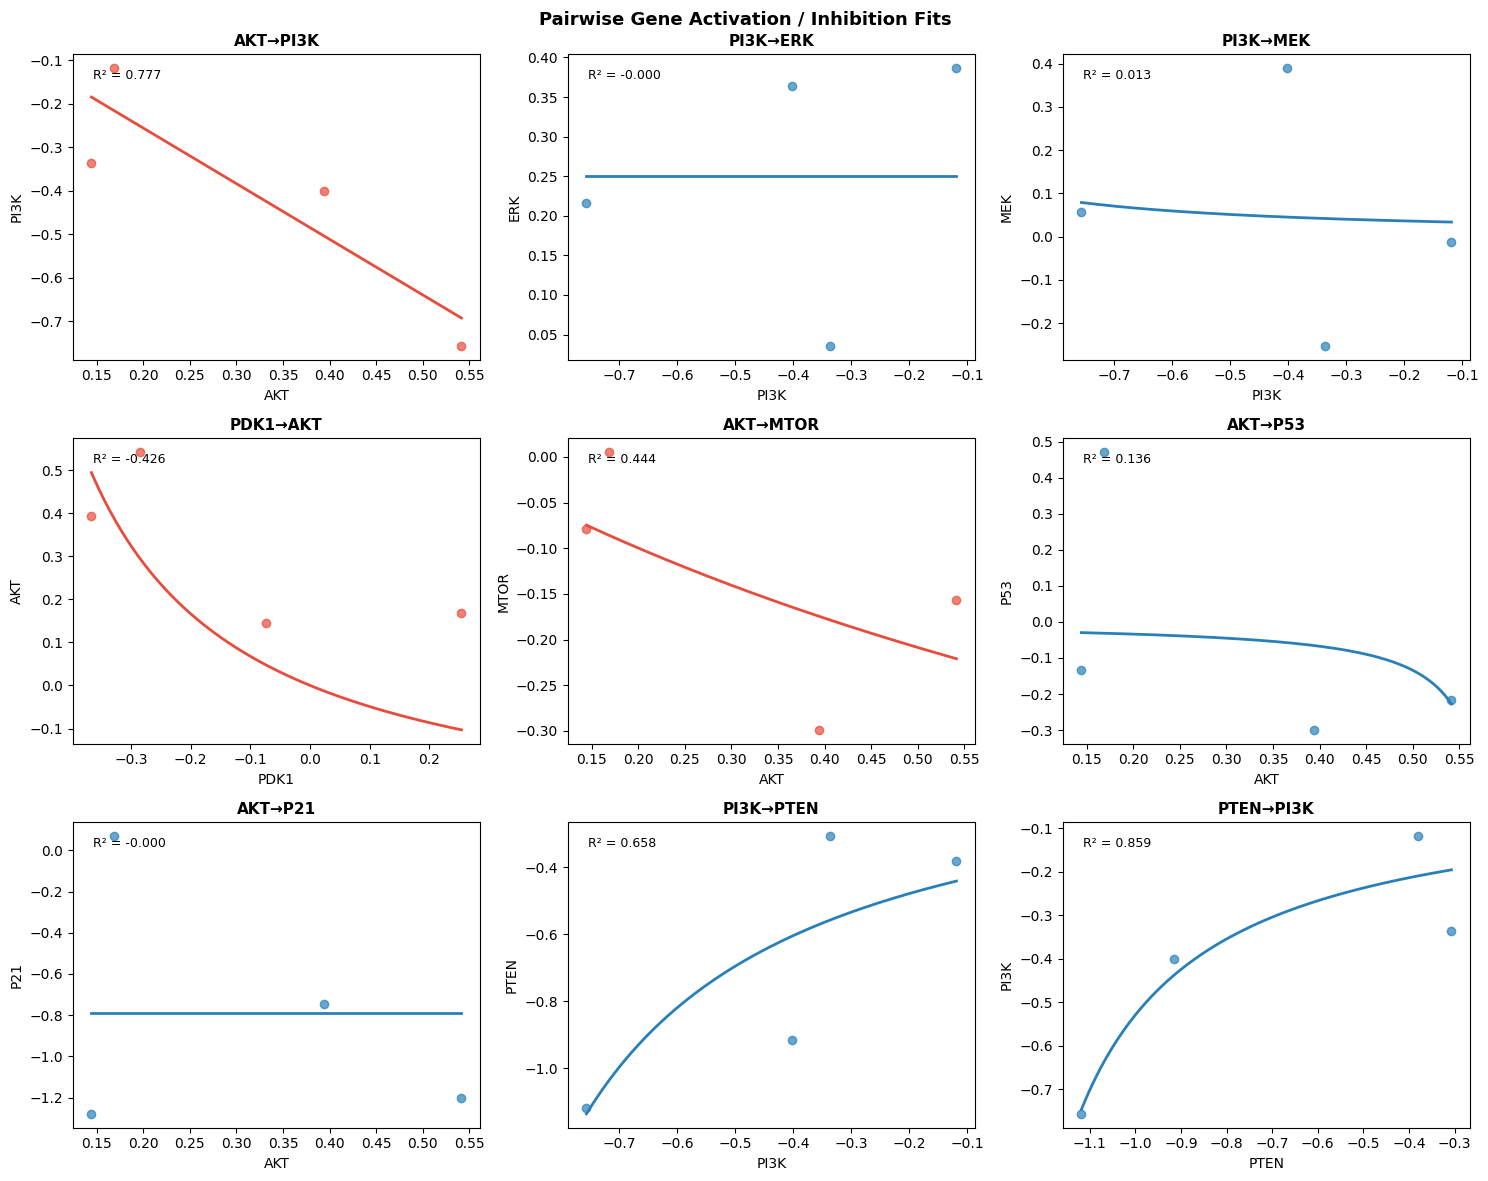

In [7]:
# ── Plot all fits ─────────────────────────────────────────────────────────────

n = len(results_pairs)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (label, res) in enumerate(results_pairs.items()):
    ax = axes[i]
    pair = res["pair"]
    x_seq = np.linspace(pair["up"].min(), pair["up"].max(), 200)
    y_seq = res["func"](x_seq, *res["params"])

    color = "#e74c3c" if res["form"] == "activation" else "#2980b9"
    ax.scatter(pair["up"], pair["down"], color=color, alpha=0.7, zorder=3)
    ax.plot(x_seq, y_seq, color=color, linewidth=2)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(res["upstream"])
    ax.set_ylabel(res["downstream"])
    ax.text(0.05, 0.92, f"R² = {res['r2']:.3f}", transform=ax.transAxes, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Pairwise Gene Activation / Inhibition Fits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

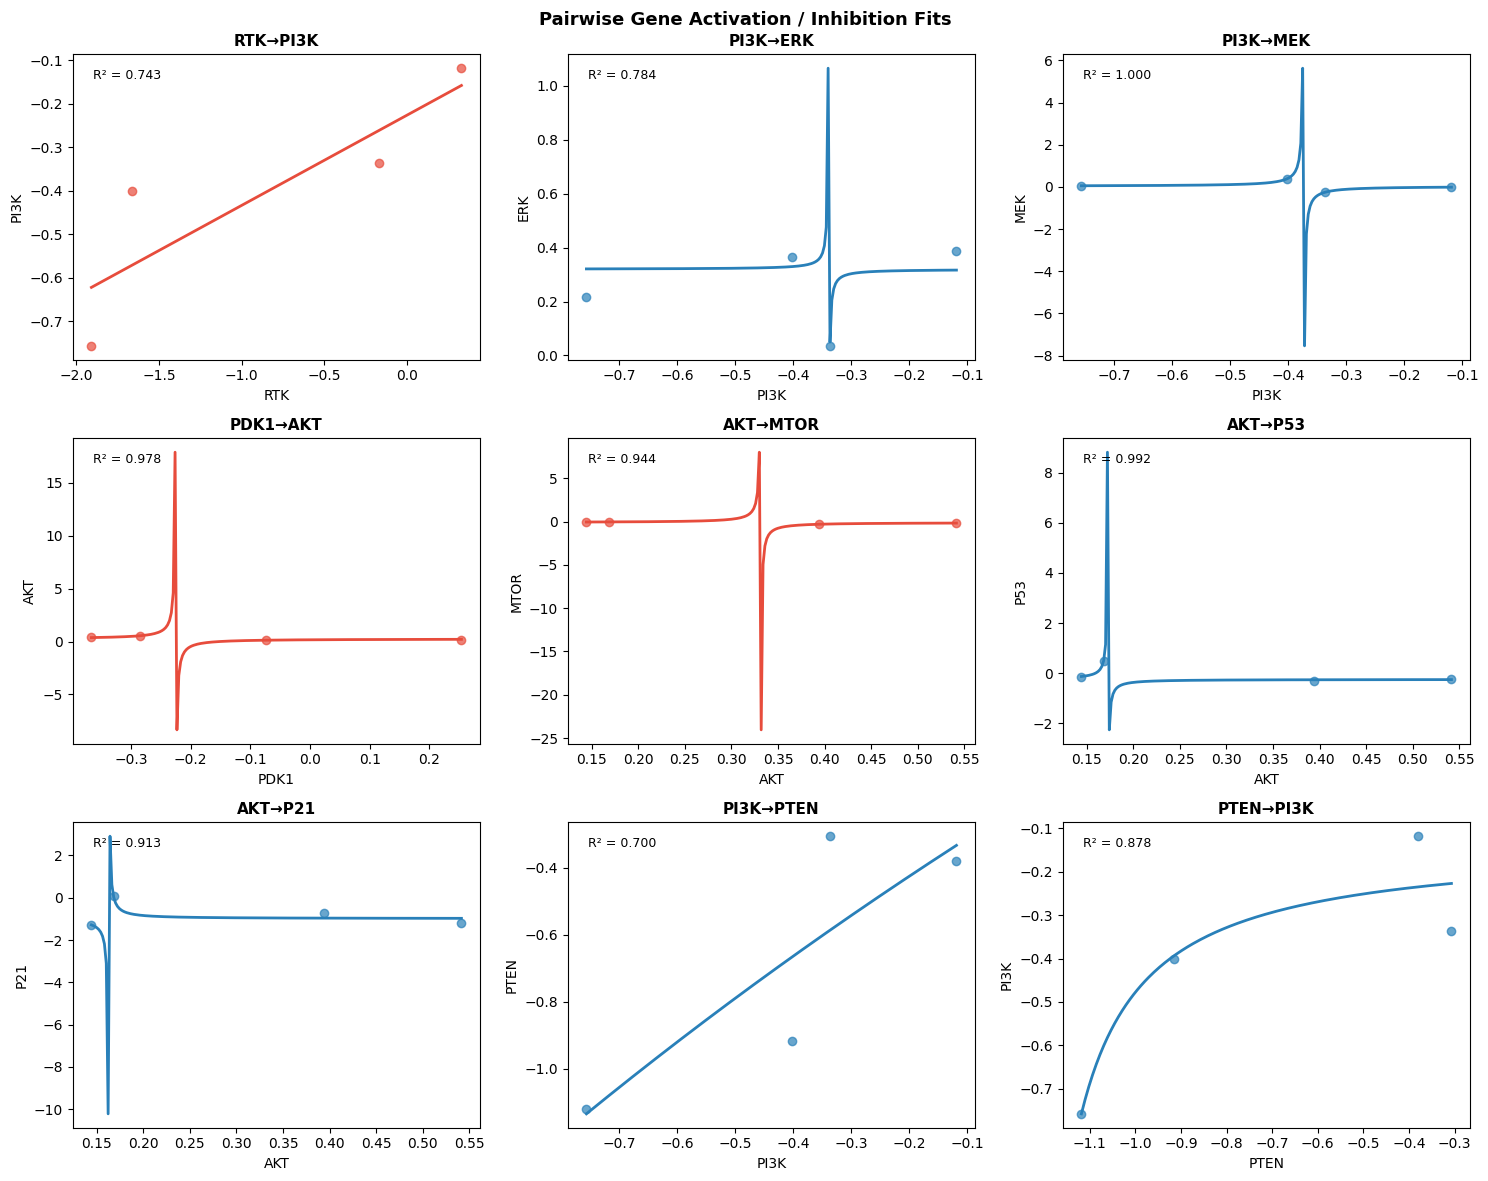

In [34]:
# correct with RTK

n = len(results_pairs)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (label, res) in enumerate(results_pairs.items()):
    ax = axes[i]
    pair = res["pair"]
    x_seq = np.linspace(pair["up"].min(), pair["up"].max(), 200)
    y_seq = res["func"](x_seq, *res["params"])

    color = "#e74c3c" if res["form"] == "activation" else "#2980b9"
    ax.scatter(pair["up"], pair["down"], color=color, alpha=0.7, zorder=3)
    ax.plot(x_seq, y_seq, color=color, linewidth=2)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(res["upstream"])
    ax.set_ylabel(res["downstream"])
    ax.text(0.05, 0.92, f"R² = {res['r2']:.3f}", transform=ax.transAxes, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Pairwise Gene Activation / Inhibition Fits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [35]:
summary.to_csv("../results_pairs_corrected.csv", index=False)

In [36]:
print(summary)

  Transition Model      R²                                     Snoopy formula
0   RTK→PI3K   mm3  0.7433  -0.2264 + (-1204657.0113 - -0.2264) / (1 + -58...
1   PI3K→ERK   mm3  0.7840   0.3174 + (0.3193 - 0.3174) / (1 + 0.3388 / PI3K)
2   PI3K→MEK   mm3  1.0000   0.0020 + (0.0297 - 0.0020) / (1 + 0.3731 / PI3K)
3   PDK1→AKT   mm3  0.9779   0.1628 + (0.2428 - 0.1628) / (1 + 0.2253 / PDK1)
4   AKT→MTOR   mm3  0.9437  -0.0677 + (-0.1043 - -0.0677) / (1 + -0.3315 /...
5    AKT→P53   mm3  0.9918  -0.2276 + (-0.2467 - -0.2276) / (1 + -0.1726 /...
6    AKT→P21   mm3  0.9126  -1.0231 + (-0.9895 - -1.0231) / (1 + -0.1628 /...
7  PI3K→PTEN   mm3  0.7004  -0.2051 + (6.1577 - -0.2051) / (1 + 5.9446 / P...
8  PTEN→PI3K   mm3  0.8781  -0.2037 + (-0.1312 - -0.2037) / (1 + 1.2650 / ...


In [8]:
# ── Summary table → Snoopy arc weights ───────────────────────────────────────

summary = pd.DataFrame([
    {
        "Transition":  k,
        "Form":        v["form"],
        "Vmax":        round(v["vmax"], 4),
        "K":           round(v["k"],    4),
        "R²":          round(v["r2"],   4),
        "Snoopy formula": (
            f"{v['vmax']:.4f} * {v['upstream']} / ({v['k']:.4f} + {v['upstream']})"
            if v["form"] == "activation" else
            f"{v['vmax']:.4f} / (1 + {v['upstream']} / {v['k']:.4f})"
        )
    }
    for k, v in results_pairs.items()
])

print(summary.to_string(index=False))

Transition       Form          Vmax             K      R²                               Snoopy formula
  AKT→PI3K activation -2.324123e+07  1.816673e+07  0.7768 -23241225.2322 * AKT / (18166732.8905 + AKT)
  PI3K→ERK inhibition  2.506000e-01  4.553535e+06 -0.0000           0.2506 / (1 + PI3K / 4553534.9702)
  PI3K→MEK inhibition  3.030000e-02  1.229200e+00  0.0133                 0.0303 / (1 + PI3K / 1.2292)
  PDK1→AKT activation -3.608000e-01  6.342000e-01 -0.4263             -0.3608 * PDK1 / (0.6342 + PDK1)
  AKT→MTOR activation -7.624000e-01  1.326700e+00  0.4439               -0.7624 * AKT / (1.3267 + AKT)
   AKT→P53 inhibition -2.260000e-02 -6.015000e-01  0.1362                -0.0226 / (1 + AKT / -0.6015)
   AKT→P21 inhibition -7.890000e-01  5.021248e+06 -0.0000           -0.7890 / (1 + AKT / 5021248.2470)
 PI3K→PTEN inhibition -3.962000e-01  1.161900e+00  0.6580                -0.3962 / (1 + PI3K / 1.1619)
 PTEN→PI3K inhibition -1.529000e-01  1.406400e+00  0.8594                

In [28]:
# CORRECT WITH RTK-PI3K

summary = pd.DataFrame([
    {
        "Transition":  k,
        "Form":        v["form"],
        "Vmax":        round(v["vmax"], 4),
        "K":           round(v["k"],    4),
        "R²":          round(v["r2"],   4),
        "Snoopy formula": (
            f"{v['vmax']:.4f} * {v['upstream']} / ({v['k']:.4f} + {v['upstream']})"
            if v["form"] == "activation" else
            f"{v['vmax']:.4f} / (1 + {v['upstream']} / {v['k']:.4f})"
        )
    }
    for k, v in results_pairs.items()
])

print(summary.to_string(index=False))

KeyError: 'vmax'

In [14]:
p0_table = {
    ("RKT",  "PI3K", "activation"): [],
    ("PI3K", "ERK",  "inhibition"): [0.25,    4.5e6],
    ("PI3K", "MEK",  "inhibition"): [0.03,    1.23],
    ("PDK1", "AKT",  "activation"): [-0.36,   0.63],
    ("AKT",  "MTOR", "activation"): [-0.76,   1.33],
    ("AKT",  "P53",  "inhibition"): [-0.023, -0.60],
    ("AKT",  "P21",  "inhibition"): [-0.79,   5.0e6],
    ("PI3K", "PTEN", "inhibition"): [-0.40,   1.16],
    ("PTEN", "PI3K", "inhibition"): [-0.15,   1.41],
}

# based on summary

In [19]:
def mm2(x, d, e):
    return d / (1 + e / x)

def mm3(x, c, d, e):
    return c + (d - c) / (1 + e / x)

def ll3(x, b, d, e):
    return d / (1 + np.exp(b * (np.log(np.abs(x) + 1e-9) - np.log(np.abs(e) + 1e-9))))

PAIR_MODELS = {
    "mm2": (mm2, 2),
    "mm3": (mm3, 3),
    "ll3": (ll3, 3),
}

def get_p0(model_name, pair):
    y_min = float(pair["down"].min())
    y_max = float(pair["down"].max())
    x_med = float(pair["up"].median())
    if model_name == "mm2":
        return [y_max, x_med]
    if model_name == "mm3":
        return [y_min, y_max, x_med]
    if model_name == "ll3":
        return [1.0, y_max, x_med]

In [22]:
summary.to_csv("../results_pairs.csv", index=False)

In [42]:
import numpy as np
from scipy.optimize import curve_fit

EPS = 1e-9


def sigmoid_activation(x, k, theta):
    x = np.asarray(x)
    return 1 / (1 + np.exp(-k * (x - theta)))


def sigmoid_inhibition(x, k, theta):
    x = np.asarray(x)
    return 1 - sigmoid_activation(x, k, theta)

def fit_pair(upstream_name, downstream_name, form="activation"):

    up = means[upstream_name].rename(
        columns={"mean_log2fc": "up"}
    )

    down = means[downstream_name].rename(
        columns={"mean_log2fc": "down"}
    )

    pair = up.merge(
        down,
        on="sample_2"
    ).dropna()

    x = pair["up"].values
    y = pair["down"].values

    # normalize to 0-1
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    x_norm = (x - x_min) / (x_max - x_min + EPS)
    y_norm = (y - y_min) / (y_max - y_min + EPS)

    if form == "activation":
        func = sigmoid_activation
    else:
        func = sigmoid_inhibition

    candidate_k = [
        0.5,
        1,
        2,
        5,
        10,
        20
    ]

    candidate_theta = [
        np.quantile(x_norm,0.25),
        np.quantile(x_norm,0.5),
        np.quantile(x_norm,0.75)
    ]
    
    p0_list = [
        [k,t]
        for k in candidate_k
        for t in candidate_theta
    ]

    params, _ = curve_fit(
        func,
        x_norm,
        y_norm,
        p0=p0_list,
        maxfev=50000
    )

    k, theta = params

    y_pred = func(x_norm, *params)

    ss_res = np.sum(
        (y_norm - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_norm - y_norm.mean()) ** 2
    )

    r2 = 1 - ss_res / ss_tot

    if form == "activation":

        formula = (
            f"1/(1+exp(-{k:.4f}"
            f"*({upstream_name}-{theta:.4f})))"
        )

    else:

        formula = (
            f"1-1/(1+exp(-{k:.4f}"
            f"*({upstream_name}-{theta:.4f})))"
        )

    print(
        f"{upstream_name} → {downstream_name}"
        f" | {form}"
        f" | R² = {r2:.4f}"
    )

    print(
        f"  {downstream_name} = {formula}\n"
    )

    return {

        "upstream": upstream_name,
        "downstream": downstream_name,

        "form": form,

        "k": k,
        "theta": theta,

        "r2": r2,

        "pair": pair,

        "formula": formula,

        "x_min": x_min,
        "x_max": x_max,

        "y_min": y_min,
        "y_max": y_max
    }
    
pairs_config = [

    ("RTK",  "PI3K", "activation"),

    ("PDK1", "AKT",  "activation"),

    ("AKT",  "MTOR", "activation"),

    ("AKT",  "P53",  "inhibition"),

    ("P53",  "P21",  "activation"),

    ("PTEN", "PI3K", "inhibition"),

    ("RTK",  "MEK",  "activation"),

    ("MEK",  "ERK",  "activation"),
]



In [39]:
summary = pd.DataFrame([
    {
        "Transition": k,
        "Model": "sigmoid",
        "Type": v["form"],
        "k": round(v["k"], 4),
        "theta": round(v["theta"], 4),
        "R²": round(v["r2"], 4),
        "Snoopy formula": v["formula"],
    }
    for k, v in results_pairs.items()
])

print(summary.to_string(index=False))

Transition   Model       Type      k  theta      R²                     Snoopy formula
  RTK→PI3K sigmoid activation 3.2375 0.3635  0.7114    1/(1+exp(-3.2375*(RTK-0.3635)))
  PDK1→AKT sigmoid activation 0.1000 1.0000 -0.0589   1/(1+exp(-0.1000*(PDK1-1.0000)))
  AKT→MTOR sigmoid activation 0.1000 0.0000 -0.0478    1/(1+exp(-0.1000*(AKT-0.0000)))
   AKT→P53 sigmoid inhibition 3.8550 0.1279  0.3962  1-1/(1+exp(-3.8550*(AKT-0.1279)))
   P53→P21 sigmoid activation 5.6521 0.5313  0.7656    1/(1+exp(-5.6521*(P53-0.5313)))
 PTEN→PI3K sigmoid inhibition 0.1000 1.0000 -0.0640 1-1/(1+exp(-0.1000*(PTEN-1.0000)))
   RTK→MEK sigmoid activation 0.1000 1.0000 -0.0430    1/(1+exp(-0.1000*(RTK-1.0000)))
   MEK→ERK sigmoid activation 8.0937 0.2514  0.6675    1/(1+exp(-8.0937*(MEK-0.2514)))


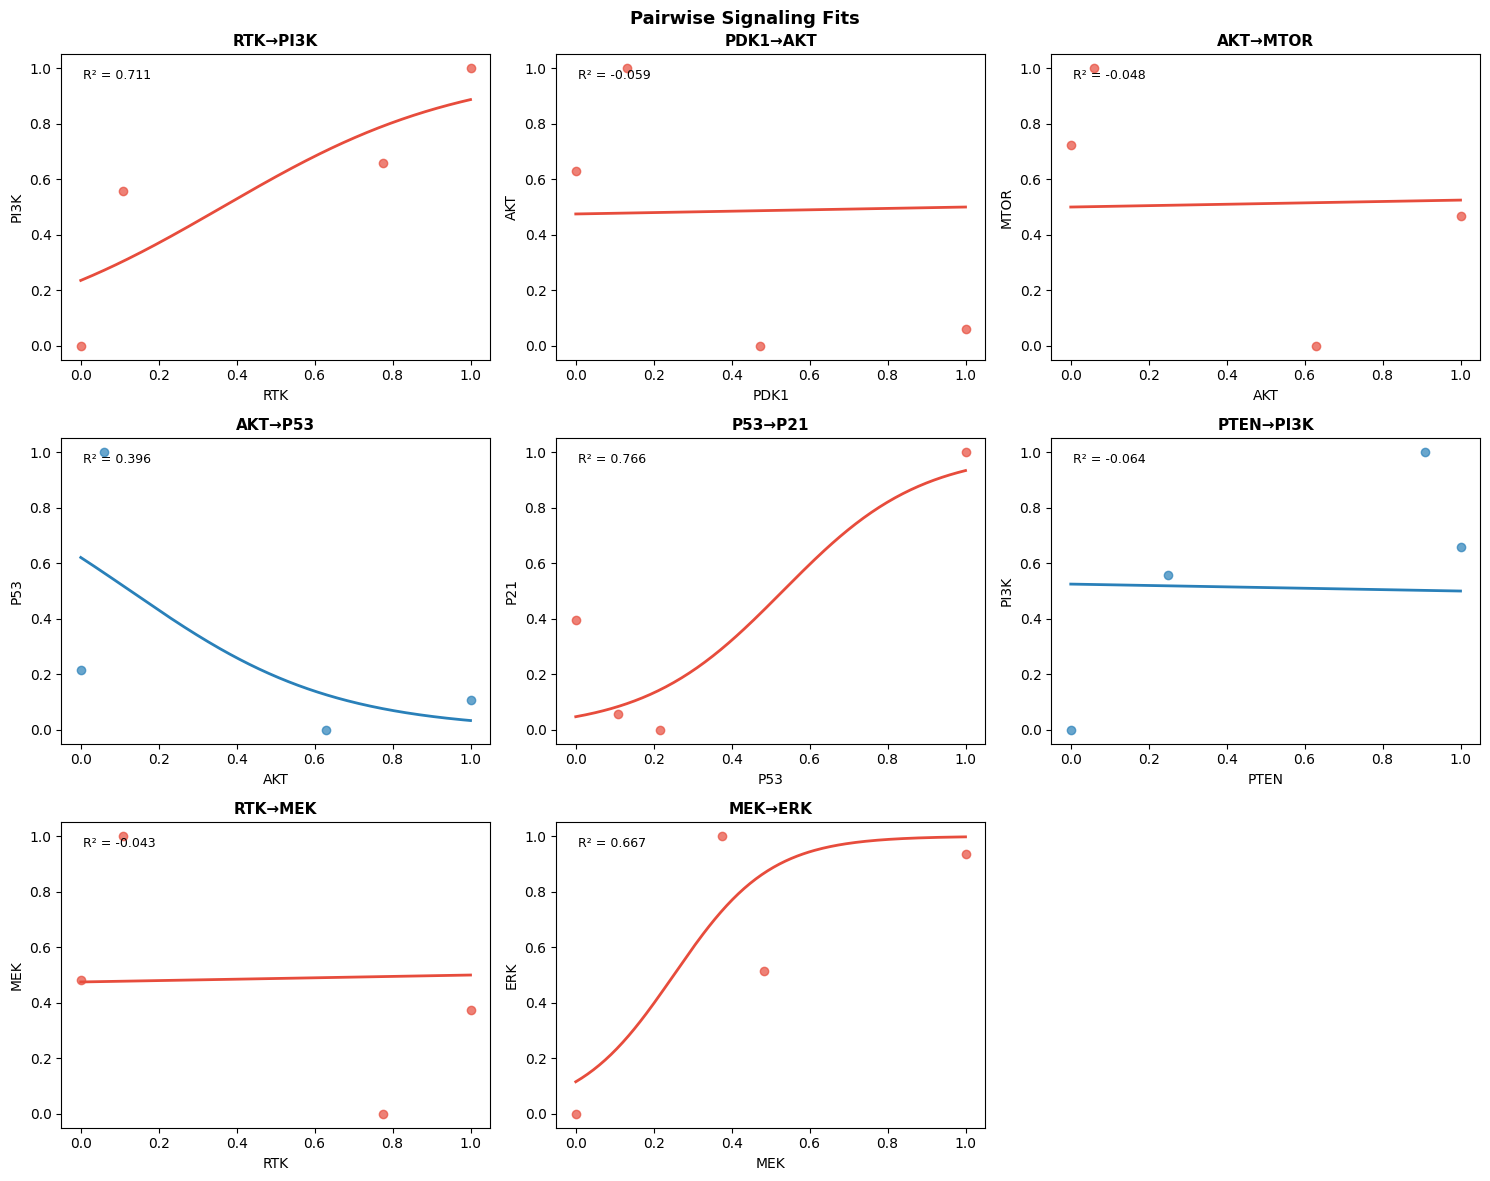

In [41]:
n = len(results_pairs)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (label, res) in enumerate(results_pairs.items()):

    ax = axes[i]

    pair = res["pair"]

    x = pair["up"].values
    y = pair["down"].values

    # same normalization as fit_pair()
    x_min = res["x_min"]
    x_max = res["x_max"]

    y_min = res["y_min"]
    y_max = res["y_max"]

    x_norm = (x - x_min) / (x_max - x_min + EPS)
    y_norm = (y - y_min) / (y_max - y_min + EPS)

    x_seq_norm = np.linspace(0, 1, 200)

    if res["form"] == "activation":
        y_seq_norm = sigmoid_activation(
            x_seq_norm,
            res["k"],
            res["theta"]
        )
        color = "#e74c3c"

    else:
        y_seq_norm = sigmoid_inhibition(
            x_seq_norm,
            res["k"],
            res["theta"]
        )
        color = "#2980b9"

    ax.scatter(
        x_norm,
        y_norm,
        color=color,
        alpha=0.7
    )

    ax.plot(
        x_seq_norm,
        y_seq_norm,
        color=color,
        linewidth=2
    )

    ax.set_title(
        label,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(res["upstream"])
    ax.set_ylabel(res["downstream"])

    ax.text(
        0.05,
        0.92,
        f"R² = {res['r2']:.3f}",
        transform=ax.transAxes,
        fontsize=9
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Pairwise Signaling Fits",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [43]:
# candicate k
summary = pd.DataFrame([
    {
        "Transition": k,
        "Model": "sigmoid",
        "Type": v["form"],
        "k": round(v["k"], 4),
        "theta": round(v["theta"], 4),
        "R²": round(v["r2"], 4),
        "Snoopy formula": v["formula"],
    }
    for k, v in results_pairs.items()
])

print(summary.to_string(index=False))

Transition   Model       Type      k  theta      R²                     Snoopy formula
  RTK→PI3K sigmoid activation 3.2375 0.3635  0.7114    1/(1+exp(-3.2375*(RTK-0.3635)))
  PDK1→AKT sigmoid activation 0.1000 1.0000 -0.0589   1/(1+exp(-0.1000*(PDK1-1.0000)))
  AKT→MTOR sigmoid activation 0.1000 0.0000 -0.0478    1/(1+exp(-0.1000*(AKT-0.0000)))
   AKT→P53 sigmoid inhibition 3.8550 0.1279  0.3962  1-1/(1+exp(-3.8550*(AKT-0.1279)))
   P53→P21 sigmoid activation 5.6521 0.5313  0.7656    1/(1+exp(-5.6521*(P53-0.5313)))
 PTEN→PI3K sigmoid inhibition 0.1000 1.0000 -0.0640 1-1/(1+exp(-0.1000*(PTEN-1.0000)))
   RTK→MEK sigmoid activation 0.1000 1.0000 -0.0430    1/(1+exp(-0.1000*(RTK-1.0000)))
   MEK→ERK sigmoid activation 8.0937 0.2514  0.6675    1/(1+exp(-8.0937*(MEK-0.2514)))


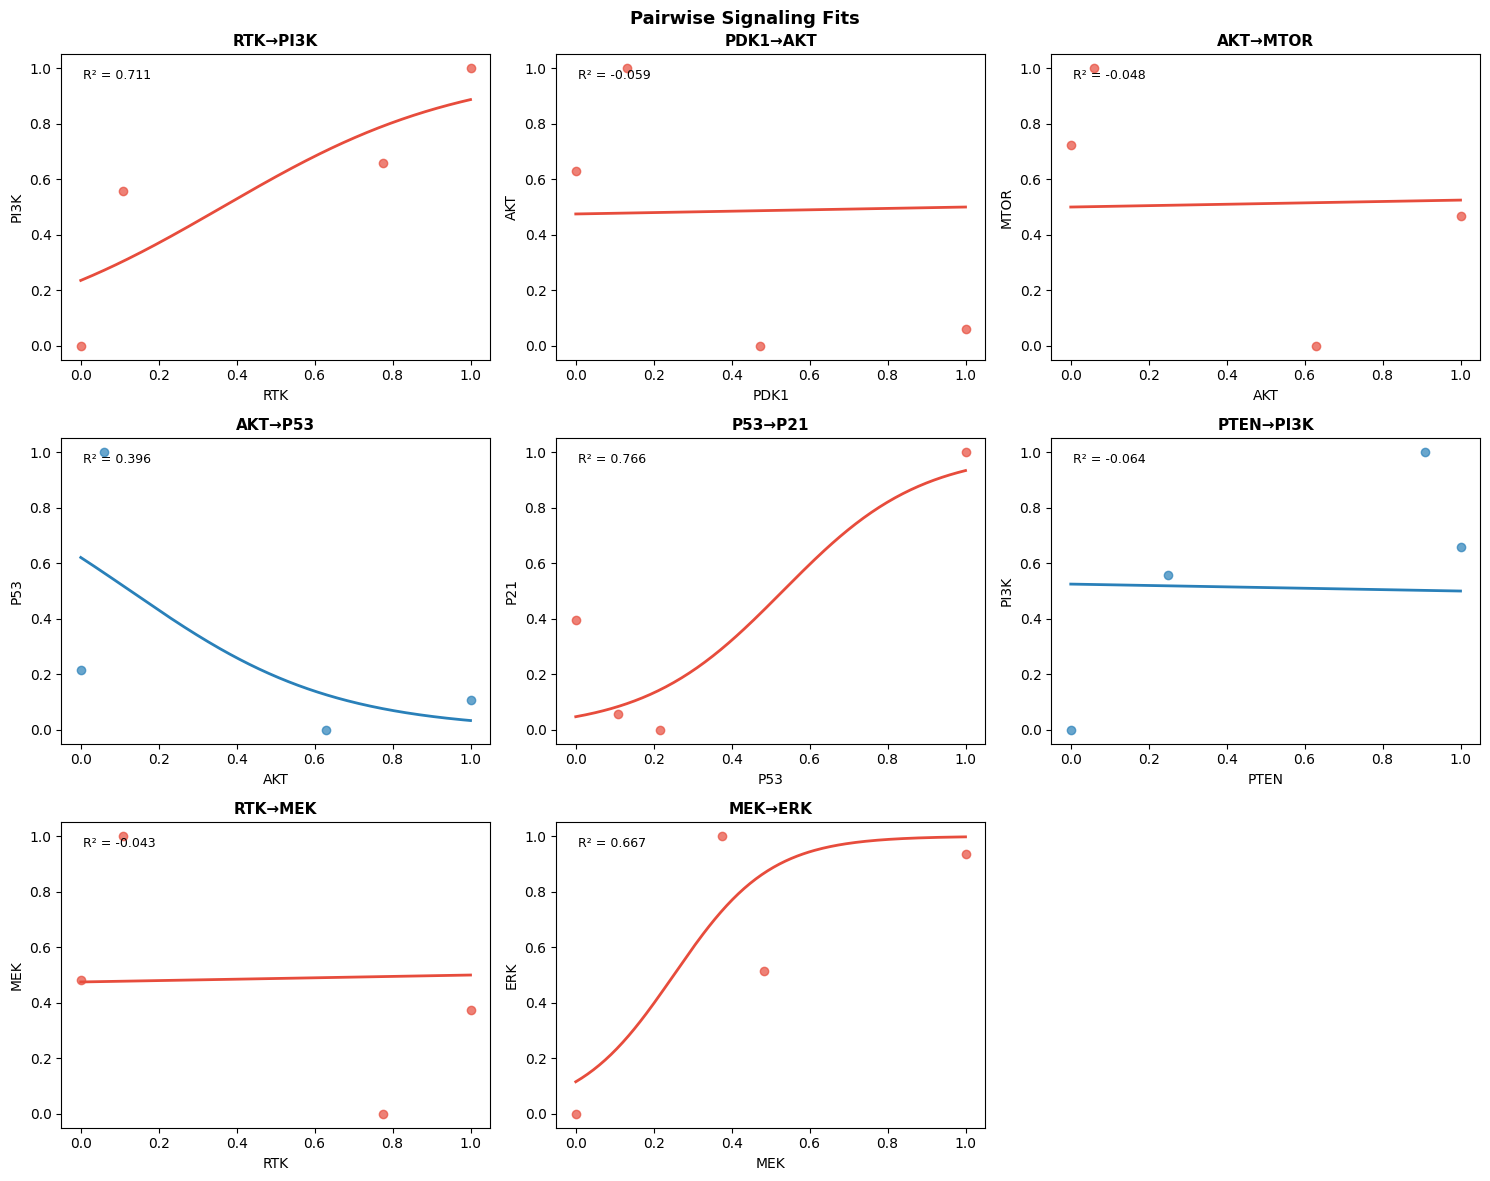

In [44]:
# candidate
n = len(results_pairs)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (label, res) in enumerate(results_pairs.items()):

    ax = axes[i]

    pair = res["pair"]

    x = pair["up"].values
    y = pair["down"].values

    # same normalization as fit_pair()
    x_min = res["x_min"]
    x_max = res["x_max"]

    y_min = res["y_min"]
    y_max = res["y_max"]

    x_norm = (x - x_min) / (x_max - x_min + EPS)
    y_norm = (y - y_min) / (y_max - y_min + EPS)

    x_seq_norm = np.linspace(0, 1, 200)

    if res["form"] == "activation":
        y_seq_norm = sigmoid_activation(
            x_seq_norm,
            res["k"],
            res["theta"]
        )
        color = "#e74c3c"

    else:
        y_seq_norm = sigmoid_inhibition(
            x_seq_norm,
            res["k"],
            res["theta"]
        )
        color = "#2980b9"

    ax.scatter(
        x_norm,
        y_norm,
        color=color,
        alpha=0.7
    )

    ax.plot(
        x_seq_norm,
        y_seq_norm,
        color=color,
        linewidth=2
    )

    ax.set_title(
        label,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(res["upstream"])
    ax.set_ylabel(res["downstream"])

    ax.text(
        0.05,
        0.92,
        f"R² = {res['r2']:.3f}",
        transform=ax.transAxes,
        fontsize=9
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Pairwise Signaling Fits",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [45]:
summary.to_csv("../results_formula.csv", index=False)